In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

### 5-Fold Cross-Validation Accuracy: 0.9475 (+/- 0.0660)

### LOGISTIC REGRESSION COEFFICIENTS (Sorted)
                                      Feature  Coefficient
13                                    TechLev     1.684324
15                                   InnoCont     1.530887
11                                      AIUse     1.477286
16                                 TrainHours     1.353020
7                                      AIConf     1.101347
12                       SpecialProjectsCount     0.863057
9                                    Feedback     0.842218
17                                  PerfScore     0.523581
3                                       Trust     0.487113
32                 RecruitmentSource_LinkedIn     0.472960
14                                     ManPos     0.467443
8                                     PsySafe     0.411714
22                        MaritalDesc_Widowed     0.362179
10                                    Network     0.359235
19        

C:\Users\dovyd\AppData\Local\Temp\ipykernel_16844\2725946645.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


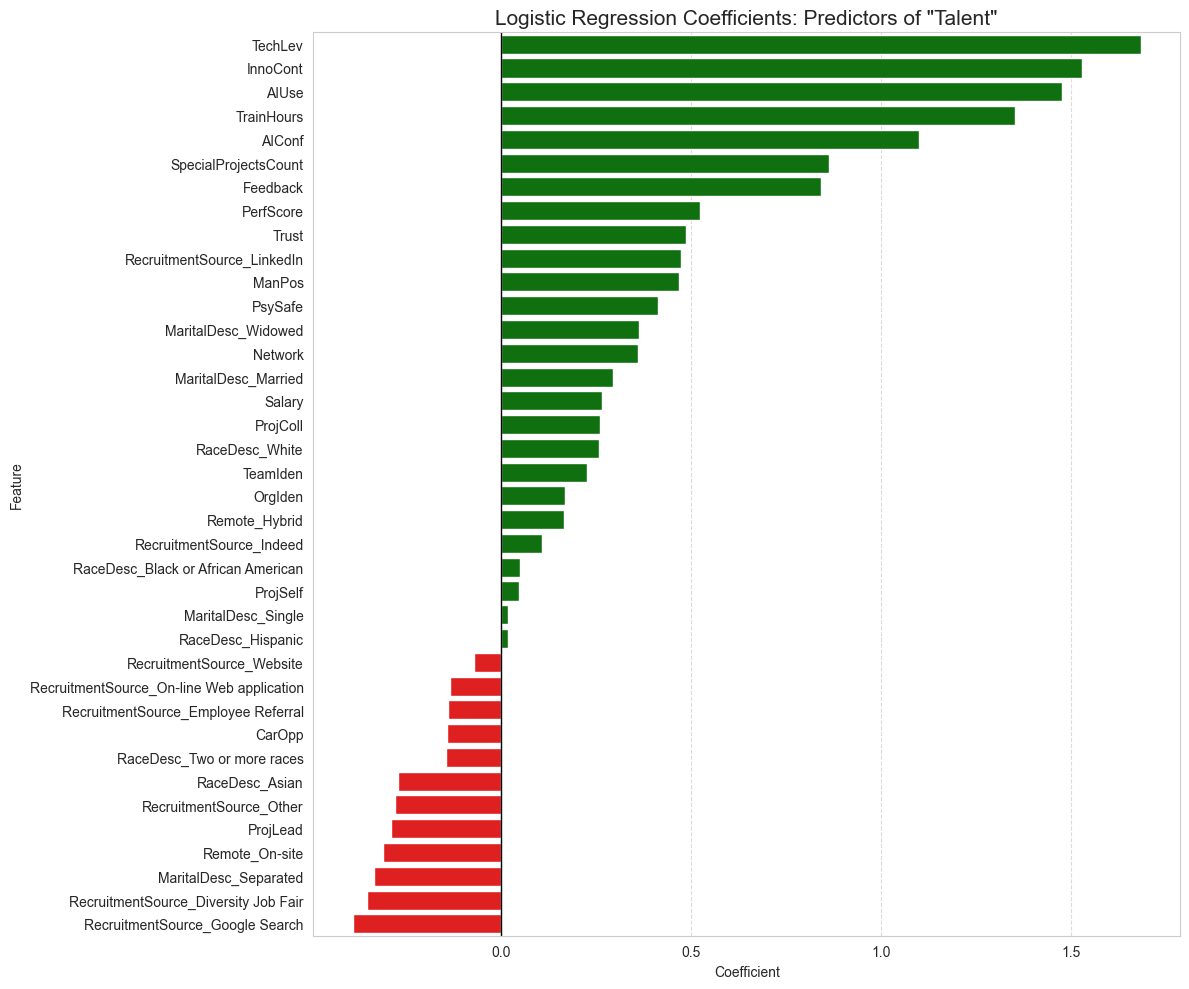

In [135]:
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

X = pd.get_dummies(df[features], drop_first=True)
y = df['is_talent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])

cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)

model_pipeline.fit(X_train, y_train)

coefs = model_pipeline.named_steps['classifier'].coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)


print(f"### 5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\n### LOGISTIC REGRESSION COEFFICIENTS (Sorted)")
print(coef_df)

y_test_pred = model_pipeline.predict(X_test)
print("\n### TEST SET CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(12, 10))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

plt.title('Logistic Regression Coefficients: Predictors of "Talent"', fontsize=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [136]:
target_map = {"Active": 0, "Voluntarily Terminated": 1}

df_filtered = df[df["EmploymentStatus"].isin(target_map)].copy()
df_filtered["Target"] = df_filtered["EmploymentStatus"].map(target_map)

features = [
    "CarOpp", "OrgIden", "ProjSelf", "Trust", "ProjColl",
    "TeamIden", "ProjLead", "AIConf", "PsySafe", "Feedback",
    "Network", "AIUse", "SpecialProjectsCount", "TechLev",
    "ManPos", "InnoCont", "TrainHours", "PerfScore", "Salary",
    "MaritalDesc", "RaceDesc", "RecruitmentSource", "Remote"
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

model_pipeline.fit(X_train, y_train)

coefs = model_pipeline.named_steps["classifier"].coef_[0]

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs
    })
    .sort_values("Coefficient", ascending=False)
)

active_users = X[y == 0]

flight_risk_probs = model_pipeline.predict_proba(active_users)[:, 1]

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f}")

print(importance_df.head(10))

risk_table = (
    pd.DataFrame({
        "Employee_Index": active_users.index,
        "Flight_Risk_Probability": flight_risk_probs
    })
    .sort_values("Flight_Risk_Probability", ascending=False)
)

print(risk_table.head(5))

5-Fold CV Accuracy: 0.8728
                                      Feature  Coefficient
17                                  PerfScore     0.835498
15                                   InnoCont     0.608995
11                                      AIUse     0.485219
33  RecruitmentSource_On-line Web application     0.420763
37                             Remote_On-site     0.398290
36                              Remote_Hybrid     0.344813
10                                    Network     0.329143
16                                 TrainHours     0.318287
30            RecruitmentSource_Google Search     0.233437
27                             RaceDesc_White     0.205264
     Employee_Index  Flight_Risk_Probability
15               23                 0.988888
50               69                 0.970494
195             288                 0.954268
80              111                 0.951967
157             230                 0.907594


In [137]:
target_map = {"Active": 0, "Voluntarily Terminated": 1}

df_filtered = df[df["EmploymentStatus"].isin(target_map)].copy()
df_filtered["Target"] = df_filtered["EmploymentStatus"].map(target_map)

features = [
    "CarOpp", "OrgIden", "ProjSelf", "Trust", "ProjColl",
    "TeamIden", "ProjLead", "AIConf", "PsySafe", "Feedback",
    "Network", "AIUse", "SpecialProjectsCount", "TechLev",
    "ManPos", "InnoCont", "TrainHours", "PerfScore", "Salary",
    "MaritalDesc", "RaceDesc", "RecruitmentSource", "Remote"
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered["Target"]

test_count = 20
test_ratio = test_count / len(df_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    stratify=y,
    random_state=42
)

model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

model_pipeline.fit(X_train, y_train)

print("Mean Accuracy:", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1:", cv_results["test_f1"].mean())

coefs = model_pipeline.named_steps["classifier"].coef_[0]

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs
    })
    .sort_values("Coefficient", ascending=False)
)

test_probs = model_pipeline.predict_proba(X_test)[:, 1]

risk_report_20 = pd.DataFrame(
    {
        "Actual_Status": y_test.map({0: "Active", 1: "Voluntarily Terminated"}).values,
        "Leaving_Probability": test_probs
    },
    index=X_test.index
)

if "Employee.Name" in df.columns:
    risk_report_20.insert(
        0,
        "Employee_Name",
        df.loc[X_test.index, "Employee.Name"].values
    )

print(risk_report_20.sort_values("Leaving_Probability", ascending=False))

y_test_pred = model_pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred))

Mean Accuracy: 0.8800000000000001
Mean Precision: 0.7923137254901962
Mean Recall: 0.8441176470588235
Mean F1: 0.8093341488658978
             Employee_Name           Actual_Status  Leaving_Probability
247          Sadki, Nore    Voluntarily Terminated             0.984421
256       Sloan, Constance  Voluntarily Terminated             0.908976
188            Miller, Ned  Voluntarily Terminated             0.902230
218     Peterson, Ebonee    Voluntarily Terminated             0.800051
147        Kampew, Donysha  Voluntarily Terminated             0.669557
304     Winthrop, Jordan    Voluntarily Terminated             0.610154
139     Jackson, Maryellen                  Active             0.465409
165       Lecter, Hannibal                  Active             0.409136
172         Lunquist, Lisa                  Active             0.201665
98          Fraval, Maruk                   Active             0.060523
274          Szabo, Andrew                  Active             0.057758
22     

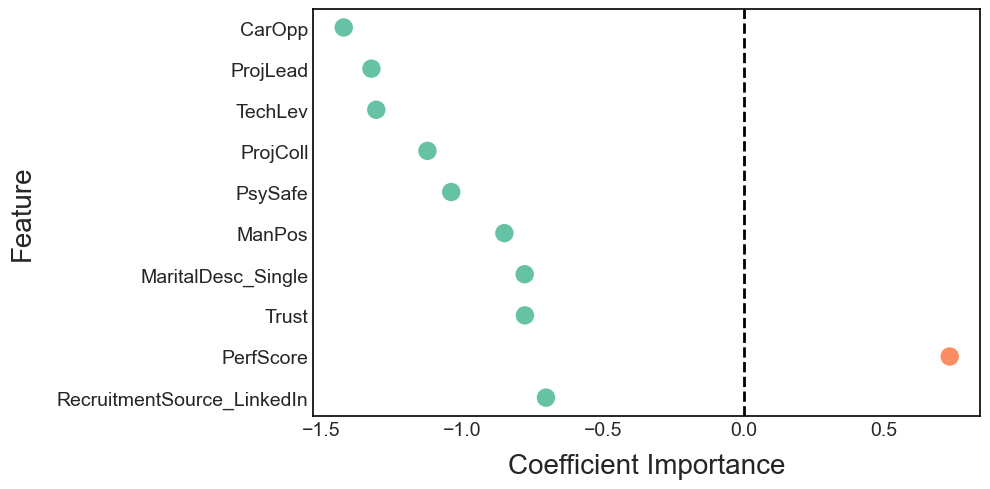

In [167]:
importance_df['Magnitude'] = importance_df['Coefficient'].abs()
top_10_features = importance_df.nlargest(10, 'Magnitude').iloc[::-1]

palette = sns.color_palette("Set2", n_colors=2)

colors = top_10_features['Coefficient'].apply(lambda x: palette[1] if x >= 0 else palette[0])

plt.figure(figsize=(10, 5))
plt.scatter(
    x=top_10_features['Coefficient'],
    y=top_10_features['Feature'],
    s=150,
    c=colors.values
)

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=14)
ax.tick_params(axis='y', length=0, labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xlabel('Coefficient Importance', fontsize=20, labelpad=10)
plt.ylabel('Feature', fontsize=20, labelpad=15)
plt.axvline(x=0, color='black', lw=2, linestyle='--')

plt.tight_layout()
plt.show()

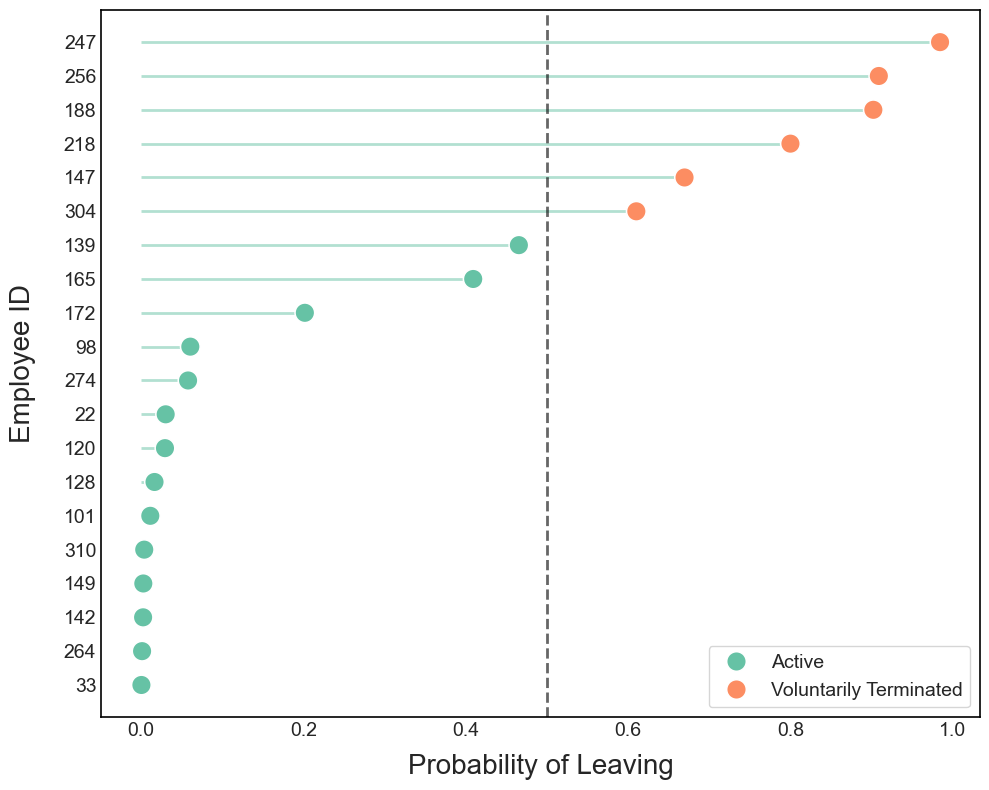

In [166]:
plot_df = risk_report_20.sort_values('Leaving_Probability', ascending=True).reset_index()
plot_df.rename(columns={'index': 'Employee_ID'}, inplace=True)

plt.figure(figsize=(10, 8))

plt.hlines(
    y=range(len(plot_df)),
    xmin=0,
    xmax=plot_df['Leaving_Probability'],
    color=palette[0],
    alpha=0.5,
    linewidth=2
)

sns.scatterplot(
    x='Leaving_Probability',
    y=range(len(plot_df)),
    hue='Actual_Status',
    data=plot_df,
    palette={'Active': palette[0], 'Voluntarily Terminated': palette[1]},
    s=200,
    zorder=3
)

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=14)
ax.tick_params(axis='y', length=0, labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.yticks(range(len(plot_df)), plot_df['Employee_ID'])

plt.xlabel('Probability of Leaving', fontsize=20, labelpad=10)
plt.ylabel('Employee ID', fontsize=20, labelpad=20)

plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.6, linewidth=2)

plt.legend(loc='lower right', fontsize=14)
plt.tight_layout()
plt.show()

### RISK ASSESSMENT: 48 ACTIVE TALENT EMPLOYEES

Q1 (25th Percentile):    0.15%
Q3 (75th Percentile):    3.96%
IQR:                     3.81%
OUTLIER THRESHOLD:       9.67%


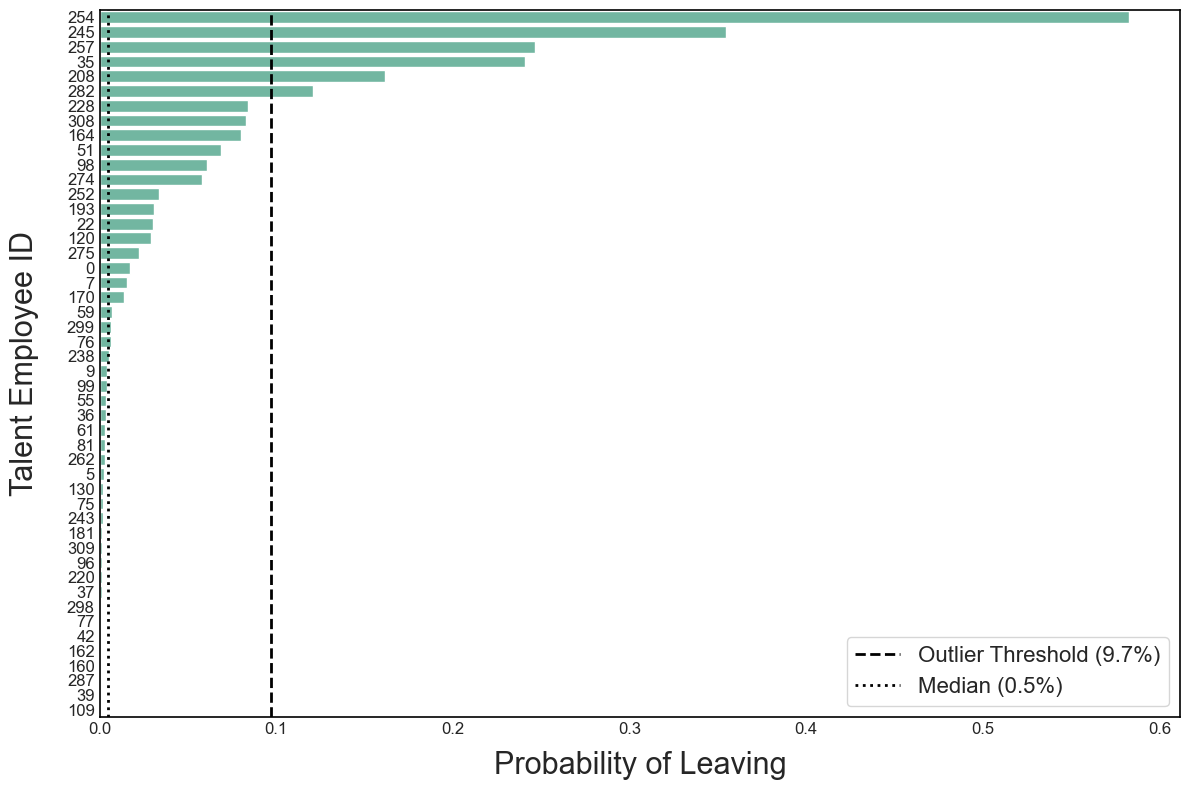

In [165]:
active_talent_df = df[(df['is_talent'] == 1) & (df['EmploymentStatus'] == 'Active')].copy()

X_active = pd.get_dummies(active_talent_df[features], drop_first=True)
X_active = X_active.reindex(columns=X.columns, fill_value=0)

active_probs = model_pipeline.predict_proba(X_active)[:, 1]

active_risk_report = pd.DataFrame({
    'Employee_ID': active_talent_df.index.astype(str),
    'Leaving_Probability': active_probs
})

Q1 = active_risk_report['Leaving_Probability'].quantile(0.25)
Q3 = active_risk_report['Leaving_Probability'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + (1.5 * IQR)

print(f"### RISK ASSESSMENT: {len(active_risk_report)} ACTIVE TALENT EMPLOYEES")

print("\n" + "="*45)
print(f"Q1 (25th Percentile):    {Q1:.2%}")
print(f"Q3 (75th Percentile):    {Q3:.2%}")
print(f"IQR:                     {IQR:.2%}")
print(f"OUTLIER THRESHOLD:       {outlier_threshold:.2%}")
print("="*45)

plt.figure(figsize=(12, 8))

plot_data = active_risk_report.sort_values('Leaving_Probability', ascending=False)

sns.barplot(
    x='Leaving_Probability',
    y='Employee_ID',
    data=plot_data,
    color=palette[0]
)

plt.axvline(outlier_threshold, color='black', linestyle='--', linewidth=2,
            label=f'Outlier Threshold ({outlier_threshold:.1%})')

median_val = active_risk_report['Leaving_Probability'].median()
plt.axvline(median_val, color='black', linestyle=':', linewidth=2,
            label=f'Median ({median_val:.1%})')

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.tick_params(axis='y', length=0, labelsize=12)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xlabel('Probability of Leaving', fontsize=22, labelpad=10)
plt.ylabel('Talent Employee ID', fontsize=22, labelpad=20)
plt.legend(loc='lower right', fontsize=16)

plt.tight_layout()
plt.show()

C:\Users\dovyd\AppData\Local\Temp\ipykernel_16844\3218864182.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


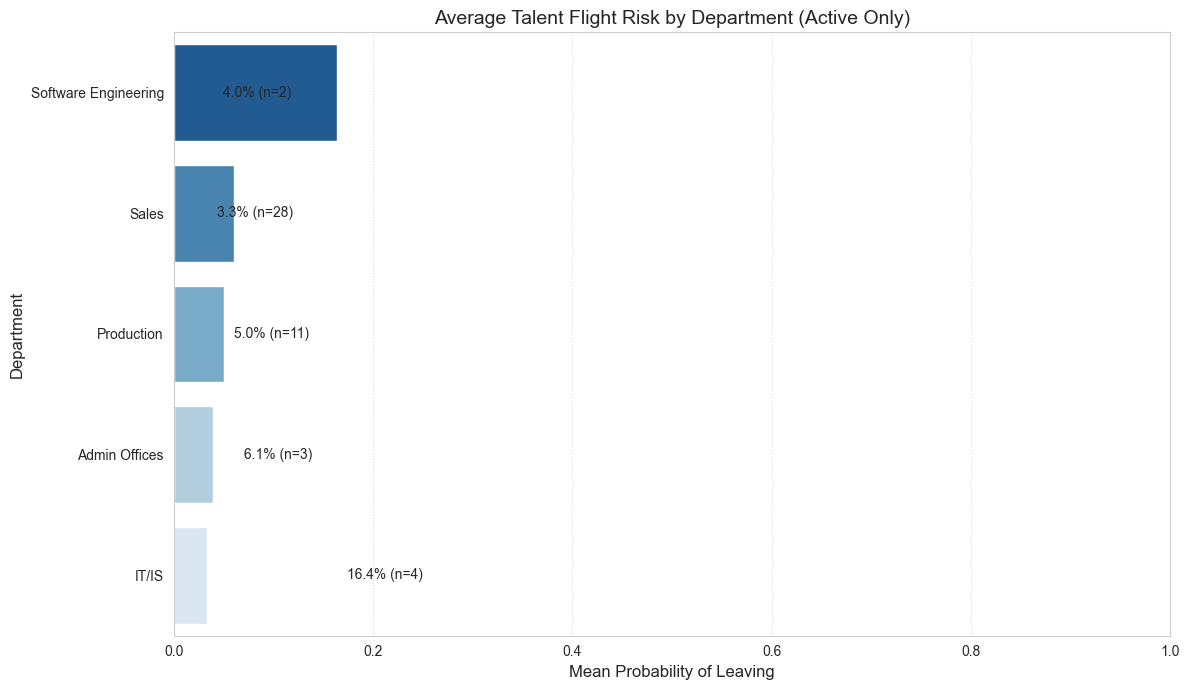

### TALENT RISK SUMMARY BY SECTOR
          Department  Mean_Risk      std  Talent_Count
Software Engineering   0.163553 0.163317             4
               Sales   0.060556 0.060189             3
          Production   0.050336 0.080661            11
       Admin Offices   0.039970 0.056268             2
               IT/IS   0.033232 0.109897            28


In [145]:
# 1. Ensure Department is included in the talent report
active_risk_report['Department'] = active_talent_df['Department'].values

# 2. Group by Department and calculate Mean and Standard Deviation
dept_risk = active_risk_report.groupby('Department')['Leaving_Probability'].agg(['mean', 'std', 'count']).reset_index()
dept_risk = dept_risk.sort_values('mean', ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 7))

# Horizontal bar plot for Mean Probability
sns.barplot(
    x='mean', 
    y='Department', 
    data=dept_risk, 
    palette='Blues_r'
)

# 4. Add labels and aesthetics
plt.title('Average Talent Flight Risk by Department (Active Only)', fontsize=14)
plt.xlabel('Mean Probability of Leaving', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.xlim(0, 1) # Probability scale
plt.grid(axis='x', linestyle=':', alpha=0.7)

# Add data labels to each bar for clarity
for i, row in dept_risk.iterrows():
    plt.text(row['mean'] + 0.01, i, f"{row['mean']:.1%} (n={int(row['count'])})", va='center')

plt.tight_layout()
plt.show()

# 5. Output summary table
print("### TALENT RISK SUMMARY BY SECTOR")
print(dept_risk.rename(columns={'mean': 'Mean_Risk', 'count': 'Talent_Count'}).to_string(index=False))

In [142]:
# 1. Map Department back to the report
active_risk_report['Department'] = active_talent_df['Department'].values

# 2. Extract the top 6 people at greatest risk
top_6_risk = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)

# 3. Add an 'Outlier_Status' flag for clarity
top_6_risk['Is_Outlier'] = top_6_risk['Leaving_Probability'] > outlier_threshold

# 4. Display the results
print("### TOP 6 HIGHEST RISK TALENTS BY SECTOR")
print(top_6_risk[['Employee_ID', 'Department', 'Leaving_Probability', 'Is_Outlier']].to_string(index=False))

# 5. Optional: Quick count of sectors in this high-risk group
print("\n### SECTOR CONCENTRATION (TOP 6)")
print(top_6_risk['Department'].value_counts())

### TOP 6 HIGHEST RISK TALENTS BY SECTOR
Employee_ID           Department  Leaving_Probability  Is_Outlier
        254                IT/IS             0.582467        True
        245 Software Engineering             0.354674        True
        257           Production             0.246323        True
         35 Software Engineering             0.240593        True
        208           Production             0.161308        True
        282                Sales             0.120762        True

### SECTOR CONCENTRATION (TOP 6)
Department
Software Engineering    2
Production              2
IT/IS                   1
Sales                   1
Name: count, dtype: int64


In [143]:
# 1. Get the Employee_IDs of the top 6 highest risk people
top_6_ids = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)['Employee_ID'].tolist()

# 2. Slice the original talent dataframe using those IDs 
# We use .astype(str) to ensure the comparison works regardless of format
top_6_full_data = active_talent_df[active_talent_df.index.astype(str).isin(top_6_ids)].copy()

# 3. Add their specific probability score so you can see it next to their data
# We map it using the index to make sure the right probability hits the right person
prob_map = active_risk_report.set_index('Employee_ID')['Leaving_Probability']
top_6_full_data['Risk_Score'] = top_6_full_data.index.astype(str).map(prob_map)

# 4. Sort by risk and display
top_6_full_data = top_6_full_data.sort_values('Risk_Score', ascending=False)

print("### FULL PROFILES: TOP 6 AT-RISK TALENTS")
# Showing the first 10 columns + Risk_Score as a sample
# Remove .iloc[:, :10] to see absolutely everything
top_6_full_data

### FULL PROFILES: TOP 6 AT-RISK TALENTS


,Employee.Name,PerfScore,PerformanceScore,GenderID,Salary,Termd,PositionID,Position,State,Zip,...,TrainHours,WLF,InnoCont,technical_score,personal_score,interpersonal_score,talent_score,is_talent,TalentStatus,Risk_Score
254,"Simard, Kramer",0.038401,Fully Meets,1,87826,0,9,Data Analyst,MA,2110,...,2.489807,0.862389,1.272193,0.965136,-0.060116,-0.015004,0.463788,1,Talent,0.582467
245,"Saada, Adell",0.038401,Fully Meets,0,86214,0,24,Software Engineer,MA,2132,...,1.139336,-0.373569,1.272193,0.787457,0.040328,-0.201055,0.353547,1,Talent,0.354674
257,"Smith, Joe",1.744516,Exceeds,1,60656,0,20,Production Technician II,MA,2045,...,1.199357,0.862389,1.272193,0.512485,0.225852,-0.064647,0.296543,1,Talent,0.246323
35,"Cady, Max",0.038401,Fully Meets,1,77692,0,25,Software Engineering Manager,MA,2184,...,0.719190,0.862389,0.135262,0.271055,0.079303,0.254919,0.219083,1,Talent,0.240593
208,"Osturnka, Adeel",1.744516,Exceeds,1,47414,0,19,Production Technician I,MA,2478,...,0.539127,-0.373569,2.409124,0.413665,0.208432,0.074185,0.277487,1,Talent,0.161308
282,"Torrence, Jack",1.744516,Exceeds,1,64397,0,3,Area Sales Manager,ND,58782,...,1.679525,-0.373569,2.409124,0.723407,0.204600,-0.105990,0.386356,1,Talent,0.120762


Recommendations for 6 people who are at the highest risk of leaving:
For all: all have low Psychological Safeness index (all -1.45 z-score, except for #3 and #5 with -0.42) and low EmpSatisfaction => making the environment safer and hiring psychologists would help

#1: ProjLead and ProjColl very low, meaning that he got poor reviews from Leader and Colleagues on the biggest project of the year. Even though JobStress low, the case may be that the person works fully remotely. The person may lack the contact with colleagues, and others dont see his work that much, thus lower feedback from colleagues may incentivize him to leave. 

#2: very technical, a lot of technical capabilities. he has a lot of special projects, but has never been a manager. job stress quite high, colleagues' low performance feedback on biggest yearly project, but leader's rating quite decent. maybe involve him in more company's activities as it feels like he has been doing well with his job, but not getting along with colleagues (high absence rate). getting along with other employees may increase his chances of becoming a manager and this would significantly lower chances of leaving

#3: she feels good with the team (TeamIden high, good reviews from colleagues) as a manager but got bad review from her leader. A bit of job stress and quite low WLF, but lacks innovation based on the leader. Everything seems fine, only thing that could be improved is OrgIden as it is low, which indicates that even though a person feels good in her team, she quite doesnt believe in the organization or doesnt feel like a part of it => align her interests and values with the companies

#4: technical, innovative, good performance review from the leader and himself, quite high OrgIden. a thing that should change is the team he/she is in as TeamIden is low as well as performance reviews from colleagues. also the person doesnt have special projects and has never been a leader, so suggesting to a person that if he keeps up the good work, he might become a manager or lead on some special projects => incentivize him to work the same as he worked before with better position

#5: innovative, but not the most technical, but seems like he doesnt feel as neither a part of a team nor a part of organization. this could be due to him working full remotely, even though his performance is good, he doesnt have informal relationships with his colleagues, whcih could be improved with hybrid working and more involvement in company's activities, more special projects

#6: WLF (work-life balance) super poor; letting him work from home more often or take more holidays would be nice; good technical score but low interpersonal score; has a lot of special projects, ProjSelf high but ProjLed low, meaning that he likes to think of himself as performing better than he actually is. quite high JobStress
